# Modelling a Flexible Mesh

**TUTORIAL STATUS**
- currently a copy of my personal learning doc
- Need to eliminate as much extra junk from boiilerplate as possible
- Visualization to do:
    - get rid of stupid trame visualization issue from pv.Plotter
    - fix other overly complicated visualization fxns
- Maybe add a few comments about the most common errors when your mesh code goes wrong and how to fixc:
    - particle out of bond
    - tether bond calc error

## Overview

### Questions

(all draft)
* 

### Objectives

- Understand the basic mechanics of meshes
- Set up correct simulations and get ready to apply mesh to simulations with particles
- Next step: add active particles from independent active particle sim to make flexicle

## Boilerplate Code

In [1]:
import math
import numpy as np
from numpy import pi, cos, sin, arccos, arange
import mpl_toolkits.mplot3d
import matplotlib.pyplot as plt
from IPython import display
import time
import gsd.hoomd
import hoomd
import matplotlib
%matplotlib inline
matplotlib.style.use('ggplot')
import matplotlib_inline
import math
import itertools 
import freud
import pandas as pd
from stl import mesh
import fresnel
import random
import pyvista as pv

The `render` function in the next (hidden) cell will render a snapshot using **fresnel**. Find the source in the [hoomd-examples](https://github.com/glotzerlab/hoomd-examples) repository.

In [2]:
# This is not intended as a full tutorial on fresnel - see the fresnel user
# documentation (https://fresnel.readthedocs.io/) if you would like to learn more.

import warnings

import fresnel
import IPython
import packaging.version

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render(snapshot):
    if ('version' not in dir(fresnel) or packaging.version.parse(
            fresnel.version.version) < FRESNEL_MIN_VERSION
            or packaging.version.parse(
                fresnel.version.version) >= FRESNEL_MAX_VERSION):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )
    central_color = fresnel.color.linear([252 / 255, 41 / 255, 0 / 255])

    L = snapshot.configuration.box[0]
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(scene,
                                       N=len(snapshot.particles.position),
                                       radius=0.5)
    geometry.material = fresnel.material.Material(color=[0, 0, 0],
                                                  roughness=0.5,
                                                  primitive_color_mix=1.0)
    geometry.position[:] = snapshot.particles.position[:]
    geometry.color[snapshot.particles.typeid[:] == 0] = central_color
    geometry.radius[snapshot.particles.typeid[:] == 0] = 0.25
    geometry.outline_width = 0.01
    box = fresnel.geometry.Box(scene, [L, L, L, 0, 0, 0], box_radius=.02)

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1),
                            color=(0.8, 0.8, 0.8),
                            theta=math.pi),
        fresnel.light.Light(direction=(1, 1, 1),
                            color=(1.1, 1.1, 1.1),
                            theta=math.pi / 3)
    ]
    scene.camera = fresnel.camera.Orthographic(position=(L * 2, L, L * 2),
                                               look_at=(0, 0, 0),
                                               up=(0, 1, 0),
                                               height=L * 1.4 + 1)
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    return IPython.display.Image(tracer.sample(scene, samples=500)._repr_png_())

### Mesh Geometry and Sim frame Initialization
- Using the tethering force: $hoomd.md.mesh.bond.Tether(mesh)$ (from 2020 Nature paper by Vutukuri et al.)
  - The triangles of the mesh need to be set up by giving each the particle IDs of the triangle tha makes up the vertices of each node.
  - Set up particles of mesh using langivin dynamics
  - At first, I am aiming to set up a static mesh.
  - Lately I will need to implement an algorithm to allow the triangles in the triangulated mesh to be redefined

Set up parameters:

In [3]:
N_mesh = 1000
mesh_radius = 10
simseed = 1
kT = 0.2
gamma = 50
mesh_gamma = 5
k_bend = 1000
k_bond = 4*k_bend
k_area = 500
dt = 0.001
#v0 = 40
simseed = 1 
rho = 0.1 #volume density of flexicle
R = 10 #radius of spherical mesh
sigma = 1 #active sphere radius

First, I will distribute the mesh on a sphere approximately using the fibancci sphere:

In [4]:
def fibonacci_sphere(num_pts, R):
    '''
    Returns points on the surface of a sphere. 
    num_pts is the number of points on the sphere.
    R is the radius of my desired mesh. 
    '''

    indices = arange(0, num_pts, dtype=float) + 0.5

    phi = arccos(1 - 2*indices/num_pts)
    theta = pi * (1 + 5**0.5) * indices

    x, y, z = R * cos(theta) * sin(phi), R * sin(theta) * sin(phi), R * cos(phi)

    return x, y, z

In [5]:
L = mesh_radius*3
x,y,z = fibonacci_sphere(num_pts=N_mesh, R=mesh_radius)
mesh_positions = np.column_stack((x,y,z))

In [6]:
'''
# This part is only applicable if we are adding active particles inside:
sphero_vol = (4/3)*np.pi*sigma**3 # volume of one active particle
N_active = int((rho * (4/3) * np.pi * R**3)/sphero_vol)
N_particles = N_mesh + N_active
'''

N_particles = N_mesh

Set up frame:

In [7]:
frame = gsd.hoomd.Frame()
frame.particles.N = N_particles
frame.particles.position = mesh_positions[0:N_particles, :]
frame.particles.typeid = [0] * N_particles
frame.configuration.box = [L, L, L, 0, 0, 0]
frame.particles.types = ['mesh']
frame.particles.mass = [1] * N_particles
frame.particles.orientation = [1,0,0,0] * N_particles

In [8]:
#### Create the Simulation Object

In [9]:
with gsd.hoomd.open(name='initial_mesh.gsd', mode='w') as f:
    f.append(frame)

In [10]:
CPU = hoomd.device.CPU()
sim = hoomd.Simulation(device=CPU, seed=simseed)
state = sim.create_state_from_gsd(filename='initial_mesh.gsd')

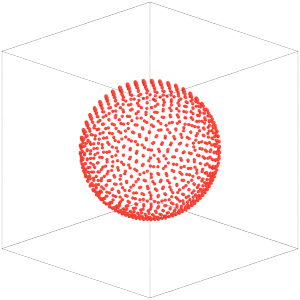

In [11]:
render(sim.state.get_snapshot())

Set up Langevin integrator:

In [12]:
integrator = hoomd.md.Integrator(dt=dt, integrate_rotational_dof=False)
sim.operations.integrator = integrator
filter_all = hoomd.filter.All()
filter_mesh = hoomd.filter.Type(['mesh'])

langevin = hoomd.md.methods.Langevin(filter=filter_all, kT=kT)
langevin.gamma.default = gamma
langevin.gamma_r.default = [gamma,gamma,gamma]
integrator.methods.append(langevin)

### Create the Simulation Mesh
- I need to find the particle tags of the particles that make up the vertices of each triangle in the triangulation.
  - To do so I will list the faces resulting from the delauney triangulation and make a list of the cartesian coordinates of each vertex on each triangle face.
  - Then, I will find which particle ID each corresponds to.
- Then, I need to pass this list into the hoomd.mesh.Mesh() data structure.
  - https://hoomd-blue.readthedocs.io/en/v4.7.0/module-hoomd-mesh.html#hoomd.mesh.Mesh

This polydata thing below is only neccessary for viewing in this jank way. (Not sure about the "trame" error I am getting, but this is solely for visualization purposes so it is not important.)

/Users/katejensen/mambaforge/envs/flex_hoomd_v4_9_1/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


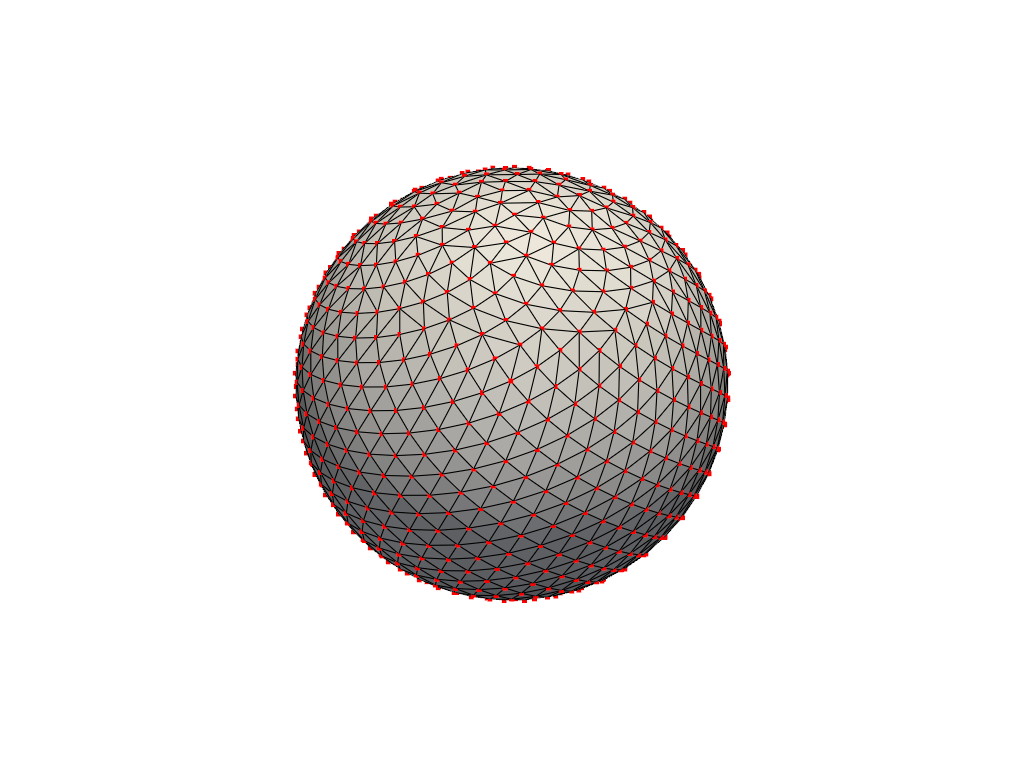

In [13]:
mesh = pv.PolyData(mesh_positions)

# Delaunay triangulation and surface extraction:
triangulated = mesh.delaunay_3d()
surface = triangulated.extract_geometry()

plotter = pv.Plotter()
plotter.add_mesh(surface, color='white', show_edges=True)
plotter.add_points(mesh_positions, color='red', point_size=5)
plotter.show()

In [14]:
# The faces array is structured with the first number being the number of points in the face 
# (should be 3 bc triangles... lmao)
faces = surface.faces.reshape((-1, 4))
triangle_points = []

for face in faces:
    if face[0] == 3:  # Check that the face is a triangle
        triangle_points.append(face[1:])

triangle_tags = np.row_stack((triangle_points))
N_triangles = len(triangle_tags)

/var/folders/1w/zpktrf8n31d3n5611bn414zh0000gn/T/ipykernel_5980/2203207025.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  triangle_tags = np.row_stack((triangle_points))


In [15]:
mesh_obj = hoomd.mesh.Mesh()
mesh_obj.types = ["mesh"]
mesh_obj.triangulation = dict(type_ids = [0] * N_triangles,
      triangles = triangle_tags)

### I need to now apply the tether potential to the mesh. 
- Using $hoomd.md.mesh.bond.Tether(mesh)$
  - https://hoomd-blue.readthedocs.io/en/v4.7.0/module-md-mesh-bond.html
  - https://hoomd-blue.readthedocs.io/en/v4.7.0/module-md-bond.html#hoomd.md.bond.Tether
- Need to figure out what my l_min, l_c1, l_c0, and l_max should be
  - Be careful that the distance between tethers should fall between l_C0 and l_C1 or else the sim could blow up.
  - I will find the largest and smallest distance between any two points in any of these triangles because these will help me decide my bounds for how I define l_c0 and l_c1
  - Also! Make sure that l_min and l_c1 are not negative. (Philipp and I found this annoying at one point)

In [16]:
triangle_cartesian_positions = frame.particles.position[triangle_tags]
global_max_edge = np.linalg.norm(triangle_cartesian_positions[:,0]-triangle_cartesian_positions[:,2],axis=1).max()
global_min_edge = np.linalg.norm(triangle_cartesian_positions[:,0]-triangle_cartesian_positions[:,2],axis=1).min()

#### Define funtions to plot the tethering bond energies for shiggles:
Still need to figure out. This is jank but it works well enough. 

In [17]:
def calc_lengths(fmin,fmax,fc1,fc0,k_b):
    l_min = global_min_edge*fmin
    l_max = global_max_edge*fmax 
    l_c1 = global_min_edge*fc1
    l_c0 = global_max_edge*fc0

    print('shortest edge length: ', global_min_edge)
    print('longest edge length: ', global_max_edge)
    print('l_max: ',l_max)
    print('l_c0: ',l_c0)
    print('l_c1: ',l_c1)
    print('l_min: ',l_min)
    print('k_b: ',k_b)
    
    return(l_min,l_max,l_c1,l_c0)

In [18]:
def find_U_bond(r):
    if r > l_c0:
        U_att = (k_bond*np.exp(1/(l_c0-r))) / (l_max-r)
    elif r <= l_c0:
        U_att = 0
    
    if r < l_c1:
        U_rep = (k_bond*np.exp(1/(r-l_c1))) / (r-l_min)
    elif r >= l_c1:
        U_rep = 0
    
    U_tot = U_att + U_rep

    return(U_att, U_rep, U_tot)

In [19]:
def plottable_energies():
    r_values = np.linspace(0, 2, 200)

    U_att_values = []
    U_rep_values = []
    U_tot_values = []
    for r in r_values:
        U_att, U_rep, U_tot = find_U_bond(r)
        U_att_values.append(U_att)
        U_rep_values.append(U_rep)
        U_tot_values.append(U_tot)

    return(r_values, U_att_values, U_rep_values, U_tot_values)

In [20]:
def plot_energies():
    plt.figure(figsize=(5, 4))
    plt.plot(r_values, U_att_values, label='U_att', color='blue')
    plt.plot(r_values, U_rep_values, label='U_rep', color='red')
    plt.plot(r_values, U_tot_values, label='U_tot', color='green')
    plt.xlabel('r')
    plt.ylabel('Potential')
    plt.title('Mesh Bond Potential vs. Distance r')
    plt.legend()
    plt.gca().set_facecolor('white') 
    plt.grid(True, color='lightgrey', linestyle =':')
    plt.axvline(x=l_min, color='grey',linestyle ='--',linewidth=1,label='l_min')
    plt.axvline(x=l_max, color='grey',linestyle ='--',linewidth=1,label='l_max')
    plt.text(l_max-0.03,max(U_tot_values)+5,'l_max',color='grey')
    plt.text(l_min-0.03,max(U_tot_values)+5,'l_min',color='grey')
    plt.axvline(x=l_c0, color='grey',linestyle ='--',linewidth=1,label='l_min')
    plt.axvline(x=l_c1, color='grey',linestyle ='--',linewidth=1,label='l_max')
    plt.text(l_c0-0.03,max(U_tot_values)+5,'l_c0',color='grey')
    plt.text(l_c1-0.03,max(U_tot_values)+5,'l_c1',color='grey')
    plt.xlim(l_min-0.1,l_max+0.1)
    plt.ylim(-5,max(U_tot_values)+10)
    plt.show()

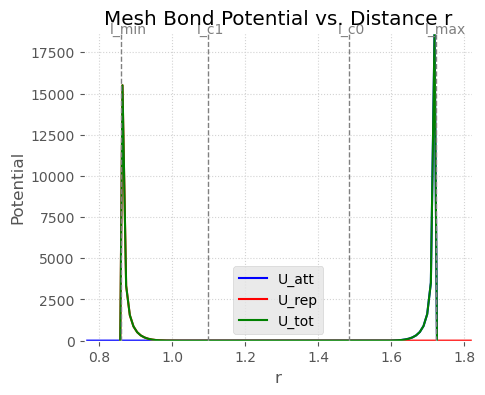

In [21]:
#fmin = 2/3
#fmax = 5/3
#fc1 = 5/6
#fc0 = 8/6

#l_min,l_max,l_c1,l_c0 = calc_lengths(fmin,fmax,fc1,fc0,k_b)

#d = global_max_edge - global_min_edge
#l_max = l_min + (4/3)*d

sigma = (global_max_edge + global_min_edge+0.003)/2 + 0.001#plot is very sensitive to this

l_min=(2/3)*sigma
l_c1=0.85*sigma
l_c0=1.15*sigma
l_max=(4/3)*sigma 

r_values, U_att_values, U_rep_values, U_tot_values = plottable_energies()
plot_energies()

Q: why the +0.003 and +0.002 to make symm??
 
A: probably bc of the way I binned my plot. Don't think its important

#### Add bonding potential to mesh

In [22]:
'''
# First, test with a harmonic bond instead:
harmonic = hoomd.md.mesh.bond.Harmonic(mesh_obj)
harmonic.params["mesh"] = dict(k=10.0, r0=0.12)
integrator.forces.append(harmonic)
'''

# Now, try tether potential
mesh_bond_potential = hoomd.md.mesh.bond.Tether(mesh_obj)
mesh_bond_potential.params["mesh"] = dict(k_b=k_bond, l_min=l_min, l_c1=l_c1,
                                 l_c0=l_c0, l_max=l_max)
integrator.forces.append(mesh_bond_potential)

#### WCA potential between all particles

In [23]:
cell = hoomd.md.nlist.Cell(buffer=0.4, exclusions=['meshbond'])
#cell = hoomd.md.nlist.Cell(buffer=ideal_buffer,mesh=mesh,exclusions=("meshbond",))

lj = hoomd.md.pair.LJ(nlist=cell,mode="shift")
lj.params[('mesh','mesh')] = dict(epsilon=1, sigma=sigma)
lj.r_cut[('mesh','mesh')] = 2**(1.0/6.)*sigma
integrator.forces.append(lj)

#### Add bonding potential to mesh (Helfrich bending potential)

In [24]:
helfrich_potential = hoomd.md.mesh.bending.Helfrich(mesh_obj)
helfrich_potential.params["mesh"] = dict(k=k_bend)
integrator.forces.append(helfrich_potential)

#### Area conservation of triangle meshes:

In [25]:
TriArea = (np.sqrt(3) / 2) * sigma**2
#AvgR, stdR = find_radius_and_deviation(sim)
TriArea = 4*np.pi*10.6**2/len(faces) # Area of triangle = surface area of mesh / number of triangles
area_potential = hoomd.md.mesh.conservation.TriangleArea(mesh_obj)
area_potential.params.default = dict(k=k_area,A0=TriArea)
integrator.forces.append(area_potential)

### Run the Simulation!

In [26]:
def find_radius_and_deviation():
    '''
    Given:
        sim: simulation object
    Determines: pos, a numpy.ndarray with each particles catersian coordinates:
    Outputs:
        AVGrad: average radius of flexicle if assume spherical.
        STDrad: standard deviation of mesh points from the avg radius value.
    '''   
    snap = sim.state.get_snapshot()
    pos = snap.particles.position
    
    rad = np.zeros(len(pos))
    for j in range(len(pos)):
        for i in list([0,1,2]):
            rad[j] += pos[j][i]**2
        rad[j] = np.sqrt(rad[j])
    AVGrad = np.mean(rad)
    STDrad = np.std(rad)
    return AVGrad, STDrad

GSD logger:

In [27]:
logger = hoomd.logging.Logger(['particle','constraint'])

# This gsd writer saves ALL particles
gsd_oper = hoomd.write.GSD(trigger=hoomd.trigger.Periodic(int(50)), filename='active.gsd',logger=logger,mode='wb',dynamic=['momentum','property'],filter=filter_all)
# This gsd writer saves the mesh particles (same as above if no active particles in the system)
#gsd_oper = hoomd.write.GSD(trigger=hoomd.trigger.Periodic(int(50)), filename='active.gsd',logger=logger,mode='wb',dynamic=['momentum','property'],filter=filter_mesh)

sim.operations += gsd_oper

Initialize the system:

radius and std of radius:  (np.float64(10.000000004299125), np.float64(2.1326029926510876e-07))


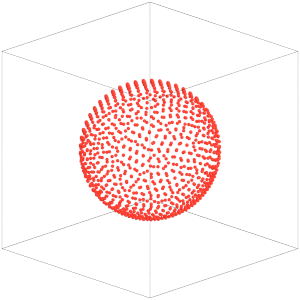

In [28]:
sim.state.thermalize_particle_momenta(filter=filter_all, kT=kT)
sim.run(0)
print('radius and std of radius: ', find_radius_and_deviation())
render(sim.state.get_snapshot())

Thermalize the system! (change to longer later)

radius and std of radius:  (np.float64(10.632112348876216), np.float64(0.06796018856172298))


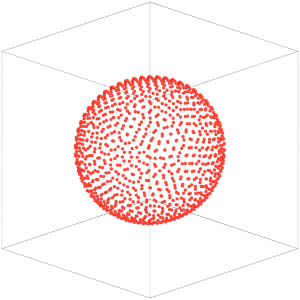

In [29]:
sim.run(20000)
gsd_oper.flush()
print('radius and std of radius: ', find_radius_and_deviation())
render(sim.state.get_snapshot())